# 黑色星期五案例分析

## 数据清洗

### 查看数据

In [1]:
import pandas as pd

df=pd.read_csv('BlackFriday.csv')
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969
...,...,...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,M,36-45,16,C,1,0,1,2.0,NaN,11664
537573,1004737,P00111142,M,36-45,16,C,1,0,1,15.0,16.0,19196
537574,1004737,P00345942,M,36-45,16,C,1,0,8,15.0,NaN,8043
537575,1004737,P00285842,M,36-45,16,C,1,0,5,NaN,NaN,7172


In [2]:
df.shape

(537577, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537577 entries, 0 to 537576
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     537577 non-null  int64  
 1   Product_ID                  537577 non-null  object 
 2   Gender                      537577 non-null  object 
 3   Age                         537577 non-null  object 
 4   Occupation                  537577 non-null  int64  
 5   City_Category               537577 non-null  object 
 6   Stay_In_Current_City_Years  537577 non-null  object 
 7   Marital_Status              537577 non-null  int64  
 8   Product_Category_1          537577 non-null  int64  
 9   Product_Category_2          370591 non-null  float64
 10  Product_Category_3          164278 non-null  float64
 11  Purchase                    537577 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 49.2+ MB


In [4]:
df=df.rename(
    columns={
        'User_ID': '用户ID',
        'Product_ID': '商品ID',
        'Gender': '性别',
        'Age': '年龄',
        'Occupation': '职业',
        'City_Category': '城市类别',
        'Stay_In_Current_City_Years': '居住城市年数',
        'Marital_Status': '婚姻状况',
        'Product_Category_1': '产品类别1',
        'Product_Category_2': '产品类别2',
        'Product_Category_3': '产品类别3',
        'Purchase': '采购额'
    }
)
df

,用户ID,商品ID,性别,年龄,职业,城市类别,居住城市年数,婚姻状况,产品类别1,产品类别2,产品类别3,采购额
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969
...,...,...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,M,36-45,16,C,1,0,1,2.0,NaN,11664
537573,1004737,P00111142,M,36-45,16,C,1,0,1,15.0,16.0,19196
537574,1004737,P00345942,M,36-45,16,C,1,0,8,15.0,NaN,8043
537575,1004737,P00285842,M,36-45,16,C,1,0,5,NaN,NaN,7172


In [5]:
# 查看缺失值
df.dropna().shape[0]/df.shape[0]

0.3055897108693266

In [6]:
# 填充缺失数据
# df.fillna()

In [7]:
# 查看重复数据
df.drop_duplicates()    #无重复值

,用户ID,商品ID,性别,年龄,职业,城市类别,居住城市年数,婚姻状况,产品类别1,产品类别2,产品类别3,采购额
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969
...,...,...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,M,36-45,16,C,1,0,1,2.0,NaN,11664
537573,1004737,P00111142,M,36-45,16,C,1,0,1,15.0,16.0,19196
537574,1004737,P00345942,M,36-45,16,C,1,0,8,15.0,NaN,8043
537575,1004737,P00285842,M,36-45,16,C,1,0,5,NaN,NaN,7172


## 数据分析

### 销售情况统计

In [8]:
# 采购总额
df['采购额'].sum()

np.int64(5017668378)

In [9]:
# 用户人数
df.drop_duplicates('用户ID')['用户ID'].count()

np.int64(5891)

In [10]:
df.drop_duplicates('用户ID').count()

用户ID      5891
商品ID      5891
性别        5891
年龄        5891
职业        5891
城市类别      5891
居住城市年数    5891
婚姻状况      5891
产品类别1     5891
产品类别2     4097
产品类别3     1914
采购额       5891
dtype: int64

In [11]:
# 人均消费
df['采购额'].sum()/df.drop_duplicates('用户ID')['用户ID'].count()

np.float64(851751.5494822611)

In [12]:
# 商品统计
print('商品类目数量:',df.drop_duplicates('商品ID')['商品ID'].count())
print('每个商品类目销量:',df.groupby(by='商品ID')['商品ID'].count().sort_values(ascending=False))

商品类目数量: 3623
每个商品类目销量: 商品ID
P00265242    1858
P00110742    1591
P00025442    1586
P00112142    1539
P00057642    1430
             ... 
P00077242       1
P00074542       1
P00162742       1
P00065942       1
P00215142       1
Name: 商品ID, Length: 3623, dtype: int64


### 用户画像分析

In [13]:
df.head()

,用户ID,商品ID,性别,年龄,职业,城市类别,居住城市年数,婚姻状况,产品类别1,产品类别2,产品类别3,采购额
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [14]:
df_dd=df.drop_duplicates('用户ID')[
    ['用户ID','商品ID','性别','年龄','职业','城市类别','居住城市年数','婚姻状况']
].sort_values(by='用户ID')
df_dd

,用户ID,商品ID,性别,年龄,职业,城市类别,居住城市年数,婚姻状况
0,1000001,P00069042,F,0-17,10,A,2,0
4,1000002,P00285442,M,55+,16,C,4+,0
5,1000003,P00193542,M,26-35,15,A,3,0
6,1000004,P00184942,M,46-50,7,B,2,1
9,1000005,P00274942,M,26-35,20,A,1,1
...,...,...,...,...,...,...,...,...
39124,1006036,P00237642,F,26-35,15,B,4+,1
39153,1006037,P00067342,F,46-50,1,C,4+,0
155550,1006038,P00034742,F,55+,1,C,2,0
39161,1006039,P00114042,F,46-50,0,B,4+,1


In [15]:
df_dd['采购额']=df.groupby(by='用户ID')['采购额'].sum().sort_values().values
df_dd

,用户ID,商品ID,性别,年龄,职业,城市类别,居住城市年数,婚姻状况,采购额
0,1000001,P00069042,F,0-17,10,A,2,0,44108
4,1000002,P00285442,M,55+,16,C,4+,0,44432
5,1000003,P00193542,M,26-35,15,A,3,0,45551
6,1000004,P00184942,M,46-50,7,B,2,1,46070
9,1000005,P00274942,M,26-35,20,A,1,1,46091
...,...,...,...,...,...,...,...,...,...
39124,1006036,P00237642,F,26-35,15,B,4+,1,6573609
39153,1006037,P00067342,F,46-50,1,C,4+,0,6817493
155550,1006038,P00034742,F,55+,1,C,2,0,7577505
39161,1006039,P00114042,F,46-50,0,B,4+,1,8699232


In [16]:
df.groupby('用户ID').get_group(1000004)['采购额'].sum()

np.int64(205987)

#### 性别对消费能力的影响

In [17]:
df.head()

,用户ID,商品ID,性别,年龄,职业,城市类别,居住城市年数,婚姻状况,产品类别1,产品类别2,产品类别3,采购额
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [18]:
df_dd['性别'].value_counts()

性别
M    4225
F    1666
Name: count, dtype: int64

In [19]:
df_dd['性别'].value_counts().values

array([4225, 1666])

In [20]:
df_dd['性别'].value_counts().tolist()

[4225, 1666]

In [21]:
df_dd['性别'].value_counts().index

Index(['M', 'F'], dtype='object', name='性别')

In [22]:
# pyecharts
from pyecharts.globals import CurrentConfig,NotebookType
from pyecharts import options as opts
from pyecharts.charts import Pie
from pyecharts.faker import Faker

x=['男性','女性']
y=df_dd['性别'].value_counts().values.tolist()
data_pair=[list(z) for z in zip(x,y)]
c=(
    Pie()
    .add('',data_pair)
    .set_global_opts(title_opts=opts.TitleOpts(title='性别比例图'))
    .set_series_opts(label_opts=opts.LabelOpts(formatter='{b}:{c}-{d}%'))
)
c.render_notebook()

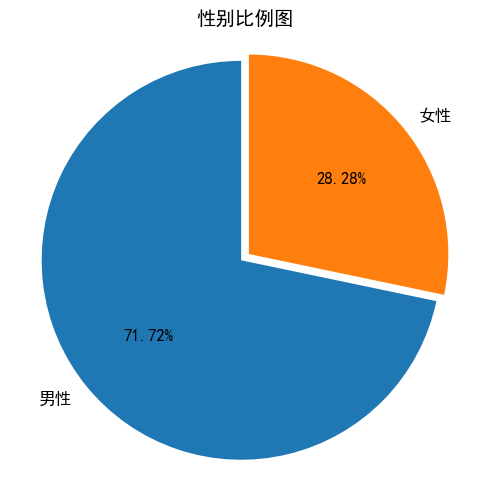

In [23]:
# seabron
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = ["SimHei"]  # 中文
plt.rcParams["axes.unicode_minus"] = False  # 负号正常显示
# sns.set_style("whitegrid")  # 设置seaborn样式

plt.figure(figsize=(5,5))

sizes=df_dd['性别'].value_counts().values
labels=['男性','女性']

plt.pie(sizes,explode=(0.05,0),labels=labels,autopct='%1.2f%%',startangle=90,textprops={'fontsize':12})
# plt.pie(sizes,labels=labels,autopct='%1.2f%%')
plt.title('性别比例图',fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()


In [25]:
# plotly
import plotly.express as px

data_p=df_dd['性别'].value_counts().tolist()
labels=['男性','女性']
fig=px.pie(values=data_p,names=labels,title='性别占比图')
fig.show()

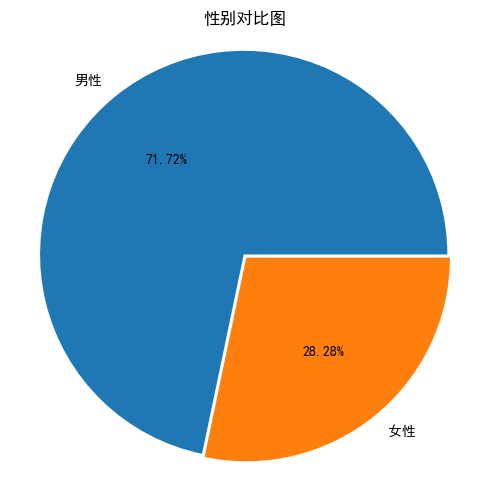

In [26]:
# matplotlib
plt.figure(figsize=(5,5))
data_m=df_dd['性别'].value_counts().values
labels=['男性','女性']
plt.pie(data_m,labels=labels,autopct='%1.2f%%',explode=(0.02,0))
plt.title('性别对比图')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [27]:
[list(z) for z in zip(Faker.choose(),Faker.values())]

[['周一', 20],
 ['周二', 95],
 ['周三', 84],
 ['周四', 28],
 ['周五', 25],
 ['周六', 100],
 ['周日', 83]]

In [28]:
data_pair

[['男性', 4225], ['女性', 1666]]

In [29]:
# 不同性别下的采购额
s_gender=df_dd.groupby(by='性别')['采购额'].sum()
s_gender

性别
F    1571217937
M    3446450441
Name: 采购额, dtype: int64

In [30]:
s_gender.values.tolist()

[1571217937, 3446450441]

In [95]:
from pyecharts import options as opts
from pyecharts.charts import Bar
c=(
    Bar()
    .add_xaxis(['男性','女性'])
    .add_yaxis('商家A',s_gender.values.tolist(),bar_width=60)
    .set_global_opts(title_opts=opts.TitleOpts(title='不同性别的采购额'))
)
c.render_notebook()

#### 婚姻状况对消费能力的影响

In [32]:
marry=df['婚姻状况'].value_counts()
marry

婚姻状况
0    317817
1    219760
Name: count, dtype: int64

In [33]:
# 婚姻状况所占比重图
from pyecharts.globals import CurrentConfig,NotebookType
from pyecharts import options as opts
from pyecharts.charts import Pie
x=['未婚','已婚']
y=marry.tolist()
data_pair=[list(z) for z in zip(x,y)]
c=(
    Pie()
    .add('',data_pair)
    .set_global_opts(title_opts=opts.TitleOpts(title='婚姻状况比例饼图'))
    .set_series_opts(lable_opts=opts.LabelOpts(formatter='{b}:{c}-{d}%'))
)
c.render_notebook()

In [34]:
# 分析不同性别下婚否对应的采购额
# 女性数据
nv_dd=df_dd[df_dd['性别']=='F']
nv_result=nv_dd.groupby(by='婚姻状况')['采购额'].sum()
nv_result

婚姻状况
0    869259499
1    701958438
Name: 采购额, dtype: int64

In [35]:
nan_dd=df_dd[df_dd['性别']=='M']
nan_result=nan_dd.groupby(by='婚姻状况')['采购额'].sum()
nan_result

婚姻状况
0    2023537268
1    1422913173
Name: 采购额, dtype: int64

In [37]:
from pyecharts import options as opts
from pyecharts.charts import Line

c=(
    Line()
    .add_xaxis(['未婚','已婚'])
    .add_yaxis('女性',nv_result.values.tolist())
    .add_yaxis('男性',nan_result.values.tolist())
    .set_global_opts(title_opts=opts.TitleOpts(title='分析不同性别婚否下对应的采购额'))
)
c.render_notebook()

#### 年龄对消费能力的影响

In [40]:
# 统计每个年龄段的人数
# 性别女数据，年龄段
nv_dd=df_dd[df_dd['性别']=='F']
nv_result=nv_dd.groupby(by='年龄')['用户ID'].count()
nv_result

年龄
0-17      78
18-25    287
26-35    545
36-45    333
46-50    182
51-55    142
55+       99
Name: 用户ID, dtype: int64

In [41]:
# 性别男数据，年龄段
nan_dd=df_dd[df_dd['性别']=='M']
nan_result=nan_dd.groupby(by='年龄')['用户ID'].count()
nan_result

年龄
0-17      140
18-25     782
26-35    1508
36-45     834
46-50     349
51-55     339
55+       273
Name: 用户ID, dtype: int64

In [43]:
# 每个年龄段男女人数统计
from pyecharts import options as opts
from pyecharts.charts import Bar

c=(
    Bar()
    .add_xaxis(nan_result.index.tolist())
    .add_yaxis('女性',nv_result.values.tolist())
    .add_yaxis('男性',nan_result.values.tolist())
    .set_global_opts(title_opts=opts.TitleOpts(title='每个年龄段男女人数统计'))
)
c.render_notebook()

In [46]:
# 每个年龄段的消费能力
cost=df_dd.groupby(by='年龄')['采购额'].sum()
cost

年龄
0-17      173133537
18-25     850215584
26-35    1864941491
36-45     989914718
46-50     466932856
51-55     395769716
55+       276760476
Name: 采购额, dtype: int64

In [47]:
# 每个年龄段消费能力
from pyecharts import options as opts
from pyecharts.charts import Bar

c=(
    Bar()
    .add_xaxis(cost.index.tolist())
    .add_yaxis('消费水平',cost.values.tolist())
    .set_global_opts(title_opts=opts.TitleOpts(title='每个年龄段消费能力统计'))
)
c.render_notebook()

#### 不同城市类别对消费能力的影响

In [56]:
df_city=df_dd['城市类别'].value_counts()
df_city

城市类别
C    3139
B    1707
A    1045
Name: count, dtype: int64

In [89]:
# 不同城市人数占比
from pyecharts.globals import CurrentConfig,NotebookType
from pyecharts import options as opts
from pyecharts.charts import Pie

x=df_city.index.tolist()
y=df_city.values.tolist()
data_pair=[list(z) for z in zip(x,y)]

c = (
    Pie()
    .add("", data_pair)
    .set_global_opts(title_opts=opts.TitleOpts(title="不同城市人数比重"))
    .set_series_opts(label_opts=opts.LabelOpts(formatter="{b}: {c}-{d}%"))
)
c.render_notebook()

In [61]:
# 不同城市人数统计
from pyecharts import options as opts
from pyecharts.charts import Bar

c = (
    Bar()
    .add_xaxis(df_city.index.tolist())
    .add_yaxis('人数', df_city.values.tolist(),bar_width=69)
    .set_global_opts(title_opts=opts.TitleOpts(title='不同城市人数统计'))
)
c.render_notebook()

In [53]:
# 不同城市的消费统计
city_sum=df_dd.groupby(by='城市类别')['采购额'].sum()
city_sum

城市类别
A     896457389
B    1501213804
C    2619997185
Name: 采购额, dtype: int64

In [91]:
from pyecharts.globals import CurrentConfig,NotebookType
from pyecharts import options as opts
from pyecharts.charts import Pie

x=city_sum.index.tolist()
y=city_sum.values.tolist()
data_pair=[list(z) for z in zip(x,y)]

c = (
    Pie()
    .add("", data_pair)
    .set_global_opts(title_opts=opts.TitleOpts(title="不同城市对消费能力的影响"))
    .set_series_opts(label_opts=opts.LabelOpts(formatter="{b}: {c}-{d}%"))
)
c.render_notebook()

In [64]:
# 不同城市人均消费
cost_pj=city_sum/df_city.sort_index()
cost_pj

城市类别
A    857853.960766
B    879445.696544
C    834659.823192
dtype: float64

In [66]:
# 不同城市人均消费统计
from pyecharts import options as opts
from pyecharts.charts import Bar

c = (
    Bar()
    .add_xaxis(cost_pj.index.tolist())
    .add_yaxis('消费额度', cost_pj.values.tolist(),bar_width=69)
    .set_global_opts(title_opts=opts.TitleOpts(title='不同城市人均消费统计'))
)
c.render_notebook()

#### 居住年数对消费的影响

In [67]:
city_live=df_dd.groupby(by='居住城市年数')['用户ID'].count()
city_live

居住城市年数
0      772
1     2086
2     1145
3      979
4+     909
Name: 用户ID, dtype: int64

In [92]:
from pyecharts.globals import CurrentConfig,NotebookType
from pyecharts import options as opts
from pyecharts.charts import Pie

x=['游客','一年','两年','三年','四年及以上']
y=city_live.values.tolist()
data_pair=[list(z) for z in zip(x,y)]

c = (
    Pie()
    .add("", data_pair)
    .set_global_opts(title_opts=opts.TitleOpts(title="城市居住年份数人数占比"))
    .set_series_opts(label_opts=opts.LabelOpts(formatter="{b}: {c}-{d}%"))
)
c.render_notebook()

In [70]:
# 城市居住年数的消费能力
years_cost=df_dd.groupby(by='居住城市年数')['采购额'].count()
years_cost

居住城市年数
0      772
1     2086
2     1145
3      979
4+     909
Name: 采购额, dtype: int64

In [93]:
from pyecharts.globals import CurrentConfig,NotebookType
from pyecharts import options as opts
from pyecharts.charts import Pie

x=['游客','一年','两年','三年','四年及以上']
y=years_cost.values.tolist()
data_pair=[list(z) for z in zip(x,y)]

c = (
    Pie()
    .add("", data_pair)
    .set_global_opts(title_opts=opts.TitleOpts(title="城市居住年数的消费水平占比"))
    .set_series_opts(label_opts=opts.LabelOpts(formatter="{b}: {c}-{d}%"))
)
c.render_notebook()

In [94]:
import pyecharts.options as opts
from pyecharts.charts import Line
from pyecharts.faker import Faker

x=['游客','一年','两年','三年','四年及以上']
y=years_cost.values.tolist()

c = (
    Line()
    .add_xaxis(x)
    .add_yaxis("消费水平", y)
    .set_global_opts(title_opts=opts.TitleOpts(title="城市居住年数的消费水平趋势"))

)
c.render_notebook()

In [74]:
from pyecharts import options as opts
from pyecharts.charts import Bar

c = (
    Bar()
    .add_xaxis(['游客','一年','两年','三年','四年及以上'])
    .add_yaxis('消费水平', years_cost.values.tolist(),bar_width=69)
    .set_global_opts(title_opts=opts.TitleOpts(title='城市居住年份消费统计'))
)
c.render_notebook()

#### 不同职业对消费的影响

In [76]:
df_dd.head()

,用户ID,商品ID,性别,年龄,职业,城市类别,居住城市年数,婚姻状况,采购额
0,1000001,P00069042,F,0-17,10,A,2,0,44108
4,1000002,P00285442,M,55+,16,C,4+,0,44432
5,1000003,P00193542,M,26-35,15,A,3,0,45551
6,1000004,P00184942,M,46-50,7,B,2,1,46070
9,1000005,P00274942,M,26-35,20,A,1,1,46091


In [83]:
# 各职业人数统计
work_count=df_dd['职业'].value_counts().sort_values()
work_count

职业
8      17
18     67
19     71
9      88
5     111
11    128
13    140
15    140
3     170
10    192
6     228
16    235
2     256
20    273
14    294
12    376
17    491
1     517
7     669
0     688
4     740
Name: count, dtype: int64

In [85]:
from pyecharts import options as opts
from pyecharts.charts import Bar

c = (
    Bar()
    .add_xaxis(work_count.index.tolist())
    .add_yaxis('消费水平', work_count.values.tolist())
    .set_global_opts(title_opts=opts.TitleOpts(title='不同职业人数统计'))
)
c.render_notebook()

In [79]:
work_cost=df_dd.groupby(by='职业')['采购额'].count()
work_cost

职业
0     688
1     517
2     256
3     170
4     740
5     111
6     228
7     669
8      17
9      88
10    192
11    128
12    376
13    140
14    294
15    140
16    235
17    491
18     67
19     71
20    273
Name: 采购额, dtype: int64

In [87]:
from pyecharts import options as opts
from pyecharts.charts import Bar

c = (
    Bar()
    .add_xaxis(work_cost.index.tolist())
    .add_yaxis('消费水平', work_cost.values.tolist())
    .set_global_opts(title_opts=opts.TitleOpts(title='不同职业消费水平统计'))
)
c.render_notebook()

## 总结

- 性别方面: 男性的消费能力比女性要高
- 婚否: 消费人数上,未婚比已婚的消费人数要多;
      已婚的人群不管是男性还是女性, 比未婚的人群消费能力要低
      总体上从未婚到已婚消费的趋势会下降, 男性下降的幅度比女性下降的幅度要大
- 年龄: 18 - 45 年龄范围的人, 消费能力要强
- 城市: BC 两城市人均消费高, 猜测可能是中大型城市, 购买力要强
- 居住年份: 随着居住年份的增加, 消费能力会降低
- 职业: 不同职业消费人数和消费能力差异化比较大, 重点可以吧营销放在人数多切消费能力高的职业上[12 17 1 7 0 4]